In [ ]:
import pandas as pd
import polars as pl
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path
import polars.selectors as cs

In [ ]:
input_folder=Path().resolve().parent /'input'
output_folder=Path().resolve().parent/'output'
output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
pl.enable_string_cache()
pl.Config.set_streaming_chunk_size(2000000)

Building customer demographics behaviour

## Importing the library defined in the working directory

In [ ]:
%%time
data=pl.scan_parquet(input_folder/'load_profile_buildingID_*')

In [ ]:
BUILDINGS=data.collect().select(pl.col('bldg_id')).unique()

#### Initial data insights

In [ ]:
data.collect().glimpse()

In [ ]:
data.collect().to_pandas().describe()

## Initial Data Preprocessing

In [ ]:
null_count=data.collect().null_count().unpivot(cs.all(), variable_name='Variable', value_name='null count')

In [ ]:
columns_to_remove=null_count.filter(pl.col('null count') > 0).select('Variable').to_series().to_list()

In [ ]:
for col in data.collect_schema().names():
    da=data.collect().filter(pl.col(col)<0).select(pl.col(col))
    if da.is_empty():
        continue
    else:
        columns_to_remove.append(col)
        

In [ ]:
data=data.drop(columns_to_remove)

#### Next step: identify outliers

In [ ]:
import importlib
import lib
importlib.reload(lib)
vis=lib.loadProfile(data)

In [ ]:
vis.boxplot_exp()

In [ ]:
vis.hist_exp()

## Data Integration Phase

In [ ]:
%%time
Meta_data=pl.scan_parquet(input_folder/'Meta_Data.parquet').with_columns(
    pl.col('bldg_id').cast(pl.UInt32)).filter(
    pl.col('bldg_id').is_in(BUILDINGS.to_series().to_list()
                           )).select(pl.col('in.occupants').cast(pl.Int32),'in.state','in.county',
                        'in.representative_income','in.area_median_income','in.income',
                        'in.income_recs_2020','in.income_recs_2015',
                        'in.building_america_climate_zone','in.ashrae_iecc_climate_zone_2004_sub_cz_split',
                        pl.col('in.bedrooms').cast(pl.Int32),'in.tenure','in.household_has_tribal_persons','bldg_id').unique()

## Merging the Meta Data into the main data

In [ ]:
data=data.join(Meta_data, on="bldg_id")

In [ ]:
null_count=data.null_count().unpivot(cs.all(),variable_name='Variable', value_name='null count')
null_count.filter(pl.col('null count')>0).collect().to_pandas()

The missing values are for building 100314 which will be removed entirely

In [ ]:
data.filter(pl.col('in.representative_income').is_null()).select(pl.all().exclude('	in.ashrae_iecc_climate_zone_2004_sub_cz_split')).collect().to_pandas()

#### Area median income is not available, type of the user is not included as well there is no signle information to impute the missing value for that

In [ ]:
# Removing the null value for that
data=data.drop_nulls()

In [ ]:
# checking if the values for that specific building ID has been removed
data.filter(pl.col('bldg_id')==100314).collect().is_empty()

## Data Transformation

#### Label Encoding for categorical variables

In [ ]:
cols=data.select(cs.string()).collect_schema().names()

In [ ]:
data.select(cols).unique().collect().to_pandas()

In [ ]:
from sklearn.preprocessing import LabelEncoder

def encode_categories(t):
    categorical_cols=t.select(cs.string()).collect_schema().names()
    le=LabelEncoder()
    encoded_data=t.with_columns(cs.string().map_batches(lambda x: le.fit_transform(x)))
    return encoded_data

data.pipe(encode_categories).select(cols).unique().collect().to_pandas()

#### Data standardization for numerical variables

In [ ]:
cols=data.select(cs.float()).collect_schema().names()

In [ ]:
data.select(cols).unique().collect().to_pandas()

In [ ]:
def transform_data(t):
    return t.with_columns(
        pl.when(cs.float().std() > 0)
        .then((cs.float() - cs.float().mean()) / cs.float().std())
        .otherwise(cs.float())
        .name.keep()
    )

data.pipe(transform_data).select(cols).unique().collect().to_pandas()

## Defining Data Dictionary

In [ ]:
schema=data.collect_schema().names()

In [ ]:
df_dictionary=pl.read_csv(input_folder/"data_dictionary.tsv", separator='\t').filter(pl.col('field_name').is_in(schema))

In [ ]:
df_dictionary.write_csv(output_folder/'data_dictionary.csv')

## Data Reduction

In [56]:
df=data.rename({'in.ashrae_iecc_climate_zone_2004_sub_cz_split': 'climatezone',
                'out.electricity.cooling.energy_consumption..kwh': 'out.electricity.AC.energy_consumption..kwh'}).with_columns(
            pl.col('timestamp').dt.weekday().alias('day of the week'),
            pl.col('timestamp').dt.hour().alias('hour of the day'),
            pl.col('timestamp').dt.day().alias('day of the month'),
            pl.col('timestamp').dt.ordinal_day().alias('day of the year'),
            pl.col('timestamp').dt.week().alias('week of the year'),
            pl.col('timestamp').dt.month().alias('month of the year'),
            pl.col('timestamp').dt.quarter().alias('quarter')).with_columns(
            pl.when(pl.col('day of the week').is_in([6,7])).then(pl.lit("Yes")).otherwise(pl.lit("No")).alias('IsWeekend')
            ).select(
    cs.matches('^out.electricity.*|^out.site_energy.*|^bldg*|^day*|^hour*|^week*|^month*|^time*|^quarter|^IsWeekend|^in.*|^Short|^climatezone$')
).collect()

## Defining Target features 

In [57]:
LONG_DURATION=['out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh']

In [58]:
INTENSITY_COLS=df.select(cs.ends_with('energy_consumption_intensity..kwh_per_ft2')).columns

In [59]:
SHORT_DURATION=df.select(
    cs.float().exclude('in.sqft','in.representative_income',
                           'out.site_energy.total.energy_consumption..kwh',
                           'out.site_energy.net.energy_consumption..kwh',
                           'out.electricity.net.energy_consumption..kwh').exclude(*LONG_DURATION).exclude(*INTENSITY_COLS)).columns

In [60]:
import importlib
import lib
importlib.reload(lib)
vis=lib.loadProfile(df)

* Checking missing values

In [ ]:
df.null_count()

#### There is missing values in the income value where the values are unknown about the income there and cannot be estimated

In [ ]:
# TODO: Do some visualizations to detect outlier--might include from the one below
# TODO: Do data transformation then and see the resulted output and measure the difference between both
# TODO: Data integration is already included
# TODO: Data reduction might be considered by doing something like PCA

## End of data preprocessing

In [ ]:
# Run boxplots
vis.boxplot_exp()

In [ ]:
# Run histograms
vis.hist_exp()

In [ ]:
# Run Boxen plot for large distributions
vis.boxen_exp()

### Now we want to see the total amount spent if its holiday or not

In [ ]:
vis.barplot_seaborn('out.electricity.total.energy_consumption..kwh', 'IsWeekend')

In [ ]:
df.head(10)

## Visualization of the long duration appliances usage

Long duration appliances are water heaters, refrigerators, Gas Stove

## First Hypothesis

the energy consumption patterns is significantly determined by the temporal attributes

In [ ]:
## TODO: Some hypotheses should be made to visulize the relationship of between divices consumption with the time pattern

### Sub Hypothesis 1: the hour of the day singificantly impact the consumption pattern of long duration appliances

In [ ]:
long_duration_hr=df.select('hour of the day', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('hour of the day').agg(pl.all().sum()).sort('hour of the day')

In [ ]:
vis.display_totals(long_duration_hr,'out.electricity.total', 'hour of the day')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_hr, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_hr,'hour of the day', 'out.electricity.AC')

In [ ]:
vis._barplot_seaborn(long_duration_hr, 'hour of the day', 'out.electricity.AC')

# Discussion
As seen in the previous plot AC usage increases towards the mid of the day and starts plummeting towards later nights

## we Found that the ac correlates more to the values to the total consumption of energy

In [ ]:
vis.long_dev_temporal_based(long_duration_hr, 'hour of the day')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_hr, 'hour of the day')

# Dicussion
The p-value for the correlation between all appliances and total consumption with the hour of the day is all less then 0.05
Indicating a strong correlation, therefore we reject the null hypothesis and we accept the alternative
therefore, hour of the day significantly determines the consumption patterns

Refrigerator has shown the highest correlation with the hour of the day column

In [ ]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.refrigerator")

In [ ]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.refrigerator")

The second strongly correlated appliance is television as people to have thier tvs on in the end of the night

In [ ]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.television")

In [ ]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.television")

____________

### Sub hypothesis 2: the day of the month singificantly impact the consumption pattern

In [ ]:
long_duration_dm=df.select('day of the month', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('day of the month').agg(pl.all().sum()).sort('day of the month')

In [ ]:
vis.display_totals(long_duration_dm,'day of the month','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_dm, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_dm,'day of the month','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_dm, 'day of the month')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_dm, 'day of the month')

In [ ]:
## TODO: Find the answer of the relationship between the day of the month and the heating appliance

## Discussion
there is a weird relationship between the heating and the day of the month which needs to be answered in this section

In [ ]:
vis.display_totals(long_duration_dm, 'day of the month',"out.electricity.heating")

In [ ]:
vis._barplot_seaborn(long_duration_dm,'day of the month',"out.electricity.heating")

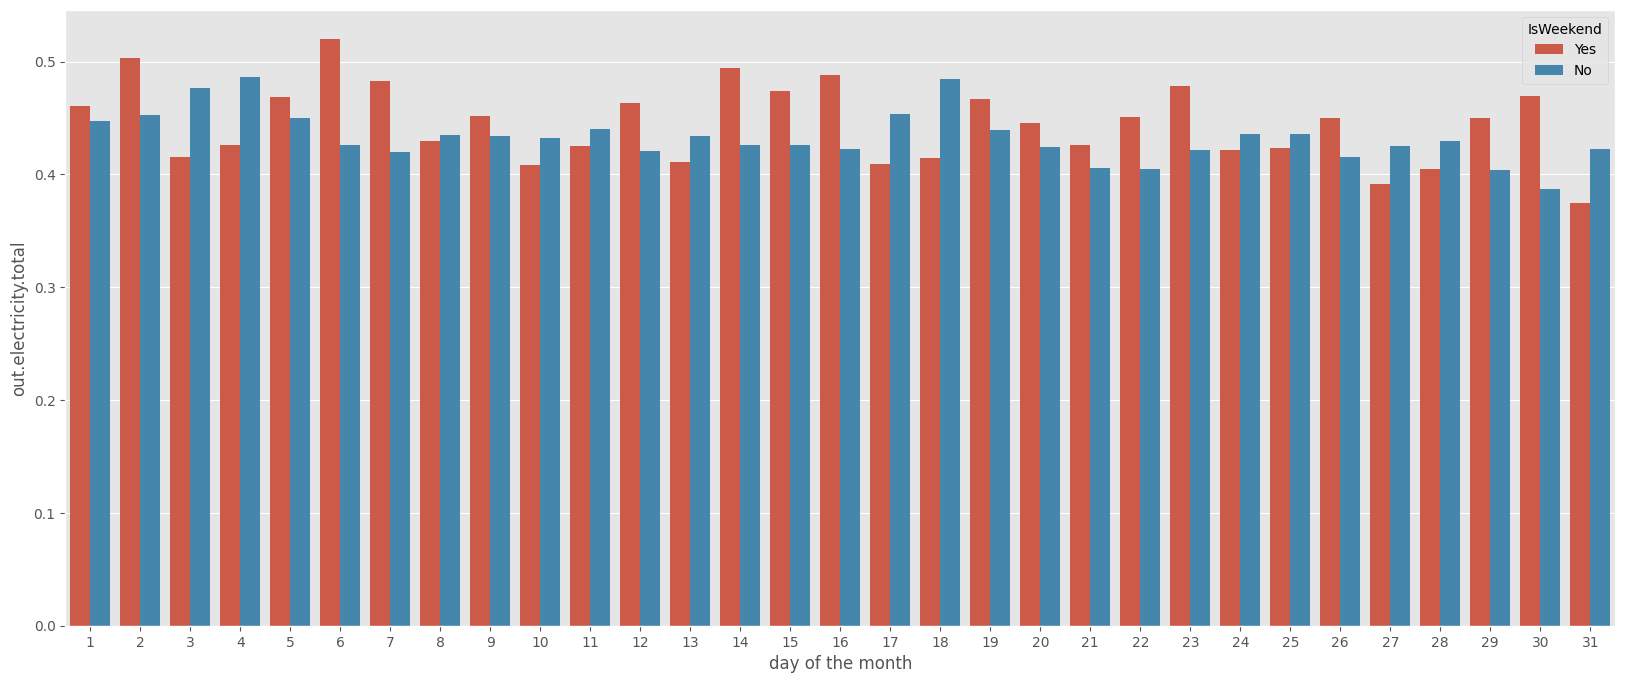

In [61]:
isweekend_df=df.select('day of the month','IsWeekend',
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('day of the month','IsWeekend').agg(
    pl.col('out.electricity.total').sum()/ pl.len()).sort('day of the month')
vis._barplot_seaborn(isweekend_df, 'day of the month', 'out.electricity.total','IsWeekend')

### Sub Hypothesis 3: the week of the year singificantly impact the consumption pattern

In [ ]:
long_duration_week=df.select('week of the year', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('week of the year').agg(pl.all().sum()).sort('week of the year')

In [ ]:
vis.display_totals(long_duration_week, 'week of the year','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_week, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_week, 'week of the year','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_week,'week of the year')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_week, 'week of the year')

## Discussion
television is mostly correlated with the weeks of the year which is also weird
let see visualization for that

In [ ]:
vis.display_totals(long_duration_week, 'week of the year',"out.electricity.television")

In [ ]:
vis._barplot_seaborn(long_duration_week,'week of the year',"out.electricity.television")

### Sub Hypothesis 4: the month of the year singificantly impact the consumption pattern

In [ ]:
long_duration_m=df.select('month of the year', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('month of the year').agg(pl.all().sum()).sort('month of the year')

In [ ]:
vis.display_totals(long_duration_m,'month of the year','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_m, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_m,'month of the year','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_m, 'month of the year')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_m, 'month of the year')

## Discussion
heating is mostly correlated with the months of the year which is also weird
let see visualization for that

In [ ]:
vis.display_totals(long_duration_m, 'month of the year',"out.electricity.heating")

In [ ]:
vis._barplot_seaborn(long_duration_m,'month of the year',"out.electricity.heating")

### Sub Hypothesis 5: the season of the year singificantly impact the consumption pattern

In [ ]:
long_duration_m=df.select('quarter', 
                            *LONG_DURATION
                           ).pipe(vis.edit_column_names).group_by('quarter').agg(pl.all().sum()).sort('quarter')

In [ ]:
vis.display_totals(long_duration_m,'quarter','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_m, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_m,'quarter','out.electricity.AC')

In [ ]:
vis.long_dev_temporal_based(long_duration_m, 'quarter')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_m, 'quarter')

## Discussion
heating is mostly correlated with the months of the year which is also weird
let see visualization for that

In [ ]:
vis.display_totals(long_duration_m, 'quarter',"out.electricity.heating")

In [ ]:
vis._barplot_seaborn(long_duration_m,'quarter',"out.electricity.heating")

## Second Hypothesis

<b> a specific subset of applainces determines the peak load period,which varies systematically by climate zone and season

# determining peak load periods --

### Distribution of site and total energy consumption monthly

In [ ]:
initial_peak=df.select(pl.col('out.electricity.total.energy_consumption..kwh','out.site_energy.total.energy_consumption..kwh','month of the year')
                 ).pipe(vis.edit_column_names).group_by('month of the year').agg(pl.all().sum())
vis.lineplot(initial_peak,'month of the year',['out.electricity.total','out.site_energy.total'])

The reason for the site energy consumption to be more than the total site energy consumption is because the site energy includes other usage and factors such as propane and gas. Total energy consumption is only collected and consumed from the appliances.

In order to make sure that the difference is the for the propoane and gas lets apply the following calculation

Checking if manually calculating the devices consumption will result in the same computation restulted in the first place

Site totals contain extra information regarding the propane gas and fuel oil, unlike the total consumption that only contains the totals of each appliance usage and doesn't related to other factors

## We determine the specific day for which the peak was there showing the distribution of all devices in that specific day

First determine the month that has the highest peak

In [ ]:
vis._barplot_seaborn(initial_peak, 'month of the year', 'out.electricity.total')

Ok now the month of the peak was septemper now lets detect the exact day

visualization for the day of the month

In [ ]:
peak_load=df.filter(pl.col('month of the year')==9).select(*LONG_DURATION, 'day of the month').pipe(vis.edit_column_names).group_by('day of the month').agg(
    pl.all().sum())
defined_columns=peak_load.columns
defined_columns.remove('day of the month')
vis.lineplot(peak_load, 'day of the month',defined_columns)

identify the day with major load

In [ ]:
vis._barplot_seaborn(peak_load, 'day of the month', 'out.electricity.total')

the major day is identified as 6th of the September

In [ ]:
peak_load_hr=df.filter(pl.col('month of the year')==9, pl.col('day of the month')==16).select(
    cs.matches('^out.electricity.*|^out.site_energy.*'),
    'hour of the day').select(*LONG_DURATION, 'hour of the day').pipe(vis.edit_column_names).group_by('hour of the day').agg(
    pl.all().sum())
defined_columns=peak_load_hr.columns
defined_columns.remove('hour of the day')
vis.lineplot(peak_load_hr, 'hour of the day',defined_columns)

identify the day with major load

In [ ]:
vis._barplot_seaborn(peak_load_hr, 'hour of the day', 'out.electricity.total')

The peak hour is identified as 16 September at 3: PM 

Now we need to see at that specific time, the site total consumption amount

In [ ]:
table=peak_load_hr.unpivot(cs.float(), index="hour of the day", variable_name="Appliances", value_name="usage").filter(
pl.col("hour of the day")==16).with_columns(pl.col('Appliances').str.strip_prefix('out.electricity.'))
vis._barplot_seaborn(table, "Appliances","usage")

### Lets measure the impact of climate zone on the distribution

#### month of the year

In [ ]:
peak_load_zone_m=df.select(
    *LONG_DURATION, 'month of the year','climatezone').pipe(vis.edit_column_names).group_by('month of the year','climatezone').agg(
    pl.all().exclude('climatezone').sum())
load_zone_melted=peak_load_zone_m.unpivot(cs.float(), index=['month of the year','climatezone'], variable_name="Appliances", value_name="usage").with_columns(
pl.col('Appliances').str.strip_prefix('out.electricity'))
vis.replot_zone(load_zone_melted, 'month of the year', 'usage','Appliances','climatezone')

In [ ]:
vis._barplot_seaborn(peak_load_zone_m, 'month of the year', 'out.electricity.total', 'climatezone')

#### day of the month

In [ ]:
peak_load_zone_d=df.filter(pl.col('month of the year')==9).select(
    *LONG_DURATION, 'day of the month','climatezone').pipe(vis.edit_column_names).group_by('day of the month','climatezone').agg(
    pl.all().exclude('climatezone').sum())
load_zone_melted=peak_load_zone_d.unpivot(cs.float(), index=['day of the month','climatezone'], variable_name="Appliances", value_name="usage").with_columns(
pl.col('Appliances').str.strip_prefix('out.electricity'))
vis.replot_zone(load_zone_melted, 'day of the month', 'usage','Appliances','climatezone')

In [ ]:
vis._barplot_seaborn(peak_load_zone_d, 'day of the month', 'out.electricity.total', 'climatezone')

#### hour of the day

In [ ]:
peak_load_zone_h=df.filter(pl.col('month of the year')==9, pl.col('day of the month')==16).select(
    *LONG_DURATION, 'hour of the day','climatezone').pipe(vis.edit_column_names).group_by('hour of the day','climatezone').agg(
    pl.all().exclude('climatezone').sum())
load_zone_melted=peak_load_zone_h.unpivot(cs.float(), index=['hour of the day','climatezone'], variable_name="Appliances", value_name="usage").with_columns(
pl.col('Appliances').str.strip_prefix('out.electricity'))
vis.replot_zone(load_zone_melted, 'hour of the day', 'usage','Appliances','climatezone')

In [ ]:
vis._barplot_seaborn(peak_load_zone_h, 'hour of the day', 'out.electricity.total', 'climatezone')

In [ ]:
table=peak_load_zone_h.unpivot(cs.float(), index=["hour of the day","climatezone"], variable_name="Appliances", value_name="usage").filter(
pl.col("hour of the day")==16).with_columns(pl.col('Appliances').str.strip_prefix('out.electricity.'))
vis._barplot_seaborn(table, "Appliances","usage","climatezone")

## Third Hypothesis

Appliances exhibit a correlated consumption pattern, combination of appliances functioning simultanously occurs more often than a random choice

in This Hypothesis we are estimating a relationship between the appliances themselves and that their operation is not random

In [ ]:
Appliances=df.group_by('bldg_id','timestamp').agg(pl.sum_horizontal(*SHORT_DURATION).alias('Short Duration Comulative'),
                                       pl.all()).explode(pl.all().exclude('bldg_id','timestamp')
                                                        ).select(*LONG_DURATION, * SHORT_DURATION,
                                                                 'hour of the day','bldg_id','day of the month',
                                                                 'month of the year','quarter','climatezone','Short Duration Comulative', cs.starts_with('in.'))

In [ ]:
# pair plot for all appliances grouped by the climate zone
targets=LONG_DURATION + ['Short Duration Comulative']
appl_rel=Appliances.select(*targets,'month of the year', 'climatezone').group_by('month of the year','climatezone').agg(pl.all().sum()).select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
plt.figure(figsize=(20,7))
vis.pairplot(appl_rel.to_pandas(),'climatezone')

In [ ]:
vis.pairplot(appl_rel.to_pandas())

#### now we will make correlation matrix to see if there is a relationship between appliances

In [ ]:
correlation_nogrp=Appliances.select(*targets).corr().select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(correlation_nogrp, correlation_nogrp.columns)

#### Monthly

In [ ]:
correlation_m=Appliances.select(*targets,'month of the year').group_by('month of the year').agg(pl.all().sum()).corr().select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(correlation_m, correlation_m.columns)

#### Seasonally

In [ ]:
correlation_q=Appliances.select(*targets,'quarter').group_by('quarter').agg(pl.all().sum()).corr().select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(correlation_q, correlation_q.columns)

#### Daily

In [ ]:
correlation_d=Appliances.select(*targets,'day of the month').group_by('day of the month').agg(pl.all().sum()).corr().select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(correlation_d, correlation_d.columns)

#### Hourly

In [ ]:
correlation_h=Appliances.select(*targets,'hour of the day').group_by('hour of the day').agg(pl.all().sum()).corr().select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(correlation_h, correlation_h.columns)

#### Letes take a deep look and see the relationship between HVAC appliances

In [ ]:
HVAC=['out.electricity.AC.energy_consumption..kwh',
      'out.electricity.heating.energy_consumption..kwh',
      'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
      'out.electricity.hot_water.energy_consumption..kwh']

In [ ]:
hvac_=Appliances.select(*HVAC).select(pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(hvac_.corr(), hvac_.columns)

#### HVAC Correlation Monthly

In [ ]:
hvac_m=Appliances.select(*HVAC,'month of the year').group_by('month of the year').agg(pl.all().sum()).select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(hvac_m.corr(), hvac_m.columns)

#### HVAC Correlation Seasonally

In [ ]:
hvac_q=Appliances.select(*HVAC,'quarter').group_by('quarter').agg(pl.all().sum()).select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(hvac_q.corr(), hvac_q.columns)

#### HVAC Correlation daily

In [ ]:
hvac_d=Appliances.select(*HVAC,'day of the month').group_by('day of the month').agg(pl.all().sum()).select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(hvac_d.corr(), hvac_d.columns)

#### HVAC Correlation Hourly

In [ ]:
hvac_h=Appliances.select(*HVAC,'hour of the day').group_by('hour of the day').agg(pl.all().sum()).select(
    pl.all().name.replace(r'^out.electricity.|.energy_consumption..kwh$',''))
vis.heatmap(hvac_h.corr(), hvac_h.columns)

What can be observed from those visualizations is that AC correlates more with cooling fans and hot water, as for heating it strongly correlates in monthly and seasonal basis which decreases when scaling timestamp more to daily and hourly. AC functions strongly correlates with the cooling fans at almost in all temporal changes, while hot water relates to both at any temporal states rather than hourly.
#### Next we Will do a line plot to see their operation in different time scales and how do they correlate

#### Monthly Basis

In [ ]:
defined_columns=hvac_m.columns
defined_columns.remove('month of the year')
vis.lineplot(hvac_m, 'month of the year',defined_columns)

#### Seasonal Basis

In [ ]:
defined_columns=hvac_q.columns
defined_columns.remove('quarter')
vis.lineplot(hvac_q, 'quarter',defined_columns)

#### daily Basis

In [ ]:
defined_columns=hvac_d.columns
defined_columns.remove('day of the month')
vis.lineplot(hvac_d, 'day of the month',defined_columns)

#### Hourly Basis

In [ ]:
defined_columns=hvac_h.columns
defined_columns.remove('hour of the day')
vis.lineplot(hvac_h, 'hour of the day',defined_columns)

#### Scatterplot for visualizing distribution

#### Pairplot to capture linear relationship

#### Montly

In [ ]:
vis.pairplot(hvac_m.to_pandas())

#### Seasonally

In [ ]:
vis.pairplot(hvac_q.to_pandas())

#### Daily

In [ ]:
vis.pairplot(hvac_d.to_pandas())

#### Hourly

In [ ]:
vis.pairplot(hvac_h.to_pandas())

#### now here we can see a clear relationship between all HVAC devices

<b> so the findings are as follows: </b>

    1. The more AC is consumed the more cooling fans is consumed. (Relationship is positive)
    2. The cooling fans are linearly correlated with the AC indicating positive relationship the more AC is used is the more cooling fans.
    3. A negative relationship between the AC and the heating, the more AC the less heating.
    4. heating is also negatively correlated with with the cooling fans the more Heatings is consumed with less cooling fans, Strong indication.
    5. AC however is positivly correlated with the hot water as hot water consumption is more in the morning.
    6. Hot water is strongly postively correlated with heating in only montly and seasonal basis.
    7. Cooling fan is negatively correlated with hot water consumption. Strong indication
    8. Refrigerator is also correlated with hot water in monthly basis which explains alot of the behavior.

## Fourth Hypothesis

user's demographic charactersitcs significantly determines energy consumptoin patterns

#### TODO: This hypothesis covers the following demographics behaviours:
    1. Comparison between buildings IDs usage, using the intensity columns to compare. (Each building ID will be associated with the total consumption)
    2. Income level and see if that significantly change the situation, Also representative income applied to determine the actual income of the customer.
    3. Income level associated with a building ID.
    4. Number of occupants in the house and their contribution to high consumption rate.
    5. nature of the household himself and its contribution towards the consuming energy.
    6. Number of rooms there adn its contribution to energy consnmption.
    7. building IDs with the climate zone.
    8. Intesity columns with climatezone

#### Examining the comparison difference between the buildings by visualizing the consumption rate that is divided by the floot area

In [ ]:
com_data=df.select(
    pl.col('bldg_id').cast(pl.String),'month of the year','day of the month','hour of the day','quarter','climatezone', 
    cs.ends_with('energy_consumption_intensity..kwh_per_ft2').name.replace(r'^out.electricity.|.energy_consumption_intensity..kwh_per_ft2$',''))

In [ ]:
pre_com=com_data.group_by('bldg_id').agg(pl.all().exclude('climatezone').sum())
vis._barplot_seaborn(pre_com, 'bldg_id', 'total')

#### Examining the relationship across climate zone

In [ ]:
pre_com=com_data.group_by('bldg_id','climatezone').agg(pl.all().sum())
vis._barplot_seaborn(pre_com, 'bldg_id', 'total','climatezone')

#### Since building with the ID 100311 is the most building consuming energy, We need to study its consumption behaviour

In [ ]:
building_100311=Appliances.filter(pl.col('bldg_id')==100311)
bar_bdlg=building_100311.select(pl.col(*targets).name.replace('^out.electricity.|.energy_consumption..kwh$',''),
                                'bldg_id','month of the year').unpivot(cs.float(), index='month of the year', variable_name='Appliance', value_name='Usage')
vis._barplot_seaborn(bar_bdlg, 'Usage','Appliance')

In [ ]:
APPL=LONG_DURATION+SHORT_DURATION
line_bldg=building_100311.select(pl.col(*APPL).name.replace('^out.electricity.|.energy_consumption..kwh$',''), 'month of the year').group_by('month of the year').agg(pl.all().sum())
columns=line_bldg.columns
columns.remove('month of the year')
vis.lineplot(line_bldg, 'month of the year',columns)

Apply correlation test to test which column correlates more to the total consumption

In [ ]:
corr_building=building_100311.select(pl.col(*APPL))
vis.test_corr(corr_building, 'out.electricity.total.energy_consumption..kwh')

#### from the following we can see that those most used appliances are dishwasher,clothes washer and lighting exterior and ceiling fans

#### Visualizing the usage of the following with long duration appliances daily

In [ ]:
DOM_APP=['out.electricity.clothes_washer.energy_consumption..kwh',
               'out.electricity.dishwasher.energy_consumption..kwh',
               'out.electricity.lighting_exterior.energy_consumption..kwh',
               'out.electricity.ceiling_fan.energy_consumption..kwh'] + LONG_DURATION

In [ ]:
vis_build=building_100311.select(
    pl.col(*DOM_APP).name.replace('^out.electricity.|.energy_consumption..kwh$',''), 'day of the month').group_by('day of the month').agg(
    pl.all().sum())
columns=vis_build.columns
columns.remove('day of the month')
vis.lineplot(vis_build, 'day of the month', columns)

In [ ]:
bar_building100311=vis_build.unpivot(cs.float(), index='day of the month', variable_name='Device', value_name='Usage')
vis._barplot_seaborn(bar_building100311, 'Usage', 'Device')

#### Sub Hypothesis 1: Income level impact the distribution of energy consumption pattern

In [ ]:
income_df=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.income').alias('income level'), pl.col('in.representative_income').alias('income value'),'month of the year')


#### First lets see the income value and level between different buildings

In [ ]:
vis._barplot_seaborn(income_df, 'bldg_id', 'income value', 'income level')

#### So building 1001 has the highest income value, now lets see how does the effect the consumption of energy by testing that with the consumption of energy

#### first measuring the income level with the total consumption

In [ ]:
vis_income=income_df.group_by('income level').agg(cs.float().sum()
                                                 ).select('income level',
                                                          pl.col(LONG_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$','')
                                                         )
vis._barplot_seaborn(vis_income, 'total', 'income level')

#### Now measuring with long duration appliances

In [ ]:
da=vis_income.unpivot(cs.float(), index='income level', variable_name='Appliances', value_name='Usage')
vis._barplot_seaborn(da, 'Usage', 'Appliances', 'income level')

#### To capture the full relationship line between income and energy consunmption, we will do a pie chart

In [ ]:
da=vis_income.group_by('income level').agg(cs.float().sum())
vis.pie(da, da['total'], da['income level'])

#### line plot to explain the relationship

In [ ]:
da=income_df.group_by('month of the year','income level').agg(
    cs.float().sum()).select(pl.col(*LONG_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$','')
                             , 'Short Duration Comulative',
                                'month of the year','income level').unpivot(
    cs.float(), index=['month of the year','income level'], variable_name='Appliances', value_name='Usage')
vis.replot_zone(da, 'month of the year','Usage','Appliances', 'income level')

#### Findings: income level with 60000 has the highest electricity usage

#### Lets test the median income for the area with its consumption patterns

In [ ]:
da=Appliances.group_by('month of the year','in.area_median_income').agg(
    cs.float().sum()).select(pl.col(*LONG_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$','')
                             , 'Short Duration Comulative',
                                'month of the year','in.area_median_income').unpivot(
    cs.float(), index=['month of the year','in.area_median_income'], variable_name='Appliances', value_name='Usage')
vis.replot_zone(da, 'month of the year','Usage','Appliances', 'in.area_median_income')

#### Sub hypothesis 2: Number of occupants significantly impact the distribution of energy consumption

In [ ]:
occupants_bar=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.occupants').alias('occupants'),'month of the year').group_by('occupants').agg(
    pl.all().sum()).select(pl.all().name.replace('^out.electricity.|.energy_consumption..kwh$',''))
vis._barplot_seaborn(occupants_bar, 'occupants', 'total')

In [ ]:
occup_df=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.occupants').alias('occupants').cast(pl.Int32),'month of the year')
occup_df.select(pl.col('occupants')).describe()

In [ ]:
vis.lineplot(occup_df, 'occupants','out.electricity.total.energy_consumption..kwh')

#### Discover the relationship of the devices with the number of occupants by making a lineplot

In [ ]:
da=occup_df.group_by('month of the year','occupants').agg(
    cs.float().sum()).select(pl.col(*LONG_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$','')
                             , 'Short Duration Comulative',
                                'month of the year','occupants').unpivot(
    cs.float(), index=['month of the year','occupants'], variable_name='Appliances', value_name='Usage')

vis.replot_zone(da, 'month of the year','Usage','Appliances', 'occupants')

#### We might suspect that the results are not propontional

In [ ]:
occup=occup_df.select(pl.all().name.replace('^out.electricity.|.energy_consumption..kwh$',''))
vis._barplot_seaborn(occup, 'bldg_id', 'total', 'occupants')

#### now the results make alot of sense there are 7 buildings out of 15 having two occupants, one building with 3 occupants, three with four and three with 5 occupants. there is only one building without any occupant which will be deleted later on

#### in order to have full view of the impact of the number of occupants we need to calculate the propotion for which each appliance is contributing with

In [ ]:
occup_pct=occup.group_by('occupants').agg(pl.col('total').sum()/pl.len())
vis._barplot_seaborn(occup_pct, 'occupants', 'total')

#### As expected the number of households significantly impact the distribution of energy consumption patterns

#### Now lets capture the relationship under certain income level

In [ ]:
occupants_df=Appliances.select(pl.col(*LONG_DURATION, *SHORT_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$',''),
                            'Short Duration Comulative','bldg_id', 
                  pl.col('in.occupants').alias('occupants').cast(pl.Int32),'month of the year', pl.col('in.income').alias('income level'))
vis.catplot(occupants_df, 'month of the year','total', 'occupants', 'income level')

#### The highest consumption rate as shown shows a high income level with 5 number of occupants confirming the correctness of the hypothesis

#### To easily understand the relationship among the consumption and the number of occupants we will do pie chart

In [ ]:
vis.pie(occup_pct, occup_pct['total'], occup_pct['occupants'])

#### Sub hypothesis 3: Nature of household significantly impact the distribution of energy consumption

In [ ]:
nature_bar=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.tenure').alias('nature'),'month of the year').group_by('nature').agg(
    pl.all().sum()).select(pl.all().name.replace('^out.electricity.|.energy_consumption..kwh$',''))
vis._barplot_seaborn(nature_bar, 'nature', 'total')

In [ ]:
nature_df=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.tenure').alias('nature'),'month of the year')
vis.lineplot(nature_df, 'nature','out.electricity.total.energy_consumption..kwh')

#### Discover the relationship of the devices with the nature of the user by making a lineplot

In [ ]:
da=nature_df.group_by('month of the year','nature').agg(
    cs.float().sum()).select(pl.col(*LONG_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$','')
                             , 'Short Duration Comulative',
                                'month of the year','nature').unpivot(
    cs.float(), index=['month of the year','nature'], variable_name='Appliances', value_name='Usage')

vis.replot_zone(da, 'month of the year','Usage','Appliances', 'nature')

#### We might suspect that the results are not propontional

In [ ]:
nat_df=nature_df.select(pl.all().name.replace('^out.electricity.|.energy_consumption..kwh$',''))
vis._barplot_seaborn(nat_df, 'bldg_id', 'total', 'nature')

#### now the results make alot of sense there are 10 buildings are owners and only 4 are renters

#### in order to have full view of the impact of the nature of occupants we need to calculate the propotion for which each appliance is contributing with

In [ ]:
nature_pct=nat_df.group_by('nature').agg(pl.col('total').sum()/pl.len())
vis._barplot_seaborn(nature_pct, 'nature', 'total')

#### As expected the nature of households significantly impact the distribution of energy consumption patterns

#### Now lets capture the relationship under certain income level

In [ ]:
user_nature_df=Appliances.select(pl.col(*LONG_DURATION, *SHORT_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$',''),
                            'Short Duration Comulative','bldg_id', 
                  pl.col('in.tenure').alias('nature'),'month of the year', pl.col('in.income').alias('income level'))
vis.catplot(user_nature_df, 'month of the year','total', 'nature', 'income level')

#### The highest consumption rate as shown shows that the nature of households significantly determines the consunmption patterns confirming the correctness of the hypothesis

#### To easily understand the relationship among the consumption and the natuer of occupants we will do pie chart

In [ ]:
vis.pie(nature_pct, nature_pct['total'], nature_pct['nature'])

#### Sub hypothesis 4: number of house rooms significantly impact the distribution of energy consumption

In [ ]:
bedrooms_bar=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.bedrooms').alias('bedroom'),'month of the year').group_by('bedroom').agg(
    pl.all().sum()).select(pl.all().name.replace('^out.electricity.|.energy_consumption..kwh$',''))
vis._barplot_seaborn(bedrooms_bar, 'bedroom', 'total')

In [ ]:
rooms_df=Appliances.select(*LONG_DURATION, *SHORT_DURATION, 'Short Duration Comulative','bldg_id', 
                  pl.col('in.bedrooms').alias('bedrooms').cast(pl.Int32),'month of the year')
rooms_df.select(pl.col('bedrooms')).describe()

In [ ]:
vis.lineplot(rooms_df, 'bedrooms','out.electricity.total.energy_consumption..kwh')

#### Discover the relationship of the devices with the number of occupants by making a lineplot

In [ ]:
da=rooms_df.group_by('month of the year','bedrooms').agg(
    cs.float().sum()).select(pl.col(*LONG_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$','')
                             , 'Short Duration Comulative',
                                'month of the year','bedrooms').unpivot(
    cs.float(), index=['month of the year','bedrooms'], variable_name='Appliances', value_name='Usage')

vis.replot_zone(da, 'month of the year','Usage','Appliances', 'bedrooms')

#### We might suspect that the results are not propontional

In [ ]:
room=rooms_df.select(pl.all().name.replace('^out.electricity.|.energy_consumption..kwh$',''))
vis._barplot_seaborn(room, 'bldg_id', 'total', 'bedrooms')

#### now the results make alot of sense there are 7 buildings out of 15 having 3 bedrooms, three buildings with four rooms and 2 with 5 rooms. total of 2 buildings with 2 bedrooms and one buildings having one bedroom.

#### in order to have full view of the impact of the number of occupants we need to calculate the propotion for which each appliance is contributing with

In [ ]:
room_pct=room.group_by('bedrooms').agg(pl.col('total').sum()/pl.len())
vis._barplot_seaborn(room_pct, 'bedrooms', 'total')

#### As expected the number of bedrooms significantly impact the distribution of energy consumption patterns

#### Now lets capture the relationship under certain income level

In [ ]:
bedrooms_df=Appliances.select(pl.col(*LONG_DURATION, *SHORT_DURATION).name.replace('^out.electricity.|.energy_consumption..kwh$',''),
                            'Short Duration Comulative','bldg_id', 
                  pl.col('in.bedrooms').alias('bedrooms').cast(pl.Int32),'month of the year', pl.col('in.income').alias('income level'))
vis.catplot(bedrooms_df, 'month of the year','total', 'bedrooms', 'income level')

#### The highest consumption rate as shown shows a high income level with 5 number of occupants confirming the correctness of the hypothesis

#### To easily understand the relationship among the consumption and the number of occupants we will do pie chart

In [ ]:
vis.pie(room_pct, room_pct['total'], room_pct['bedrooms'])